# Tarea M19-CD – Análisis de Regresión del PIB de México

En esta práctica se realiza un análisis de regresión sobre datos históricos del
Producto Interno Bruto (PIB) de México, obtenidos de los registros del Banco
Mundial.

El objetivo es ajustar un modelo logístico mediante mínimos cuadrados, evaluar
su comportamiento sobre los datos originales y sobre una versión normalizada
del conjunto de datos, y finalmente generar un pronóstico del PIB para el año
2022.

A lo largo del desarrollo se documentan los resultados obtenidos, las
dificultades encontradas en el proceso de estimación de parámetros y la bondad
de ajuste del modelo, de acuerdo con los requerimientos establecidos en la
actividad.


In [1]:
# ============================================
# Importación de librerías necesarias para el
# análisis de datos y ajuste del modelo
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================
# Configuración básica de visualización
# ============================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("default")


In [2]:
# ============================================
# Carga del conjunto de datos
# PIB histórico de México (Banco Mundial)
# ============================================

# El archivo Excel se encuentra en la raíz del proyecto
# El notebook está dentro de la carpeta "notebooks"
df = pd.read_excel("../MexicoGDP.xlsx")

# Visualización inicial del dataset
df.head()


,Periodo,GDP
0,1960,1.304000e+10
1,1961,1.416000e+10
2,1962,1.520000e+10
3,1963,1.696000e+10
4,1964,2.008000e+10


In [3]:
# ============================================
# Revisión de la estructura del conjunto de datos
# ============================================

# Dimensiones del dataset (filas, columnas)
df.shape


(62, 2)

In [4]:
# ============================================
# Revisión de nombres de columnas y tipos de datos
# ============================================

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Periodo  62 non-null     int64  
 1   GDP      62 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.1 KB


In [5]:
# ============================================
# Definición de variables independientes (X)
# y dependientes (Y)
# ============================================

# Se asume que la primera columna corresponde al año
# y la segunda columna al PIB
X = df.iloc[:, 0]
Y = df.iloc[:, 1]

X.head(), Y.head()


(0    1960
 1    1961
 2    1962
 3    1963
 4    1964
 Name: Periodo, dtype: int64,
 0    1.304000e+10
 1    1.416000e+10
 2    1.520000e+10
 3    1.696000e+10
 4    2.008000e+10
 Name: GDP, dtype: float64)

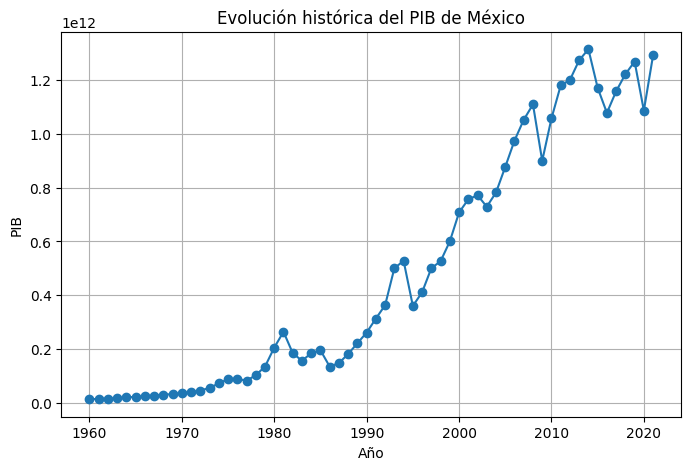

In [6]:
# ============================================
# Visualización del comportamiento histórico
# del PIB de México
# ============================================

plt.figure(figsize=(8, 5))
plt.plot(X, Y, marker="o")
plt.xlabel("Año")
plt.ylabel("PIB")
plt.title("Evolución histórica del PIB de México")
plt.grid(True)
plt.show()


In [7]:
# ============================================
# Definición del modelo logístico
# Y = 1 / (1 + e^-(beta1 + beta2 * X))
# ============================================

def modelo_logistico(x, beta1, beta2):
    return 1 / (1 + np.exp(beta1 * (x - beta2)))



In [8]:
# ============================================
# Ajuste del modelo logístico utilizando
# los datos originales (sin normalización)
# ============================================

# Estimación de los parámetros beta1 y beta2
parametros, _ = curve_fit(
    modelo_logistico,
    X,
    Y,
    maxfev=10000
)

parametros


d:\Documentos\Ebac\Finales\Tarea M19-CD – robertscience\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\RobertScience.Ia\AppData\Local\Temp\ipykernel_2040\1527784282.py:7: OptimizeWarning: Covariance of the parameters could not be estimated
  parametros, _ = curve_fit(


array([1., 1.])

Al ajustar el modelo logístico utilizando los datos originales del PIB, se
presentan dificultades en la estimación de los parámetros.

Esto se debe principalmente a la magnitud elevada de los valores del PIB, lo
cual genera problemas de estabilidad numérica durante el proceso de regresión
no lineal y afecta la convergencia del método de mínimos cuadrados.


In [9]:
# ============================================
# Normalización de las variables
# Cada observación se divide entre el valor
# máximo de su respectiva columna
# ============================================

X_norm = X / X.max()
Y_norm = Y / Y.max()

X_norm.head(), Y_norm.head()


(0    0.969817
 1    0.970312
 2    0.970807
 3    0.971301
 4    0.971796
 Name: Periodo, dtype: float64,
 0    0.009914
 1    0.010765
 2    0.011556
 3    0.012894
 4    0.015266
 Name: GDP, dtype: float64)

In [10]:
# ============================================
# Ajuste del modelo logístico utilizando
# los datos normalizados
# ============================================

# Estimación de los parámetros beta1 y beta2
parametros_norm, _ = curve_fit(
    modelo_logistico,
    X_norm,
    Y_norm,
    maxfev=10000
)

parametros_norm


array([-271.59774034,    0.9892939 ])

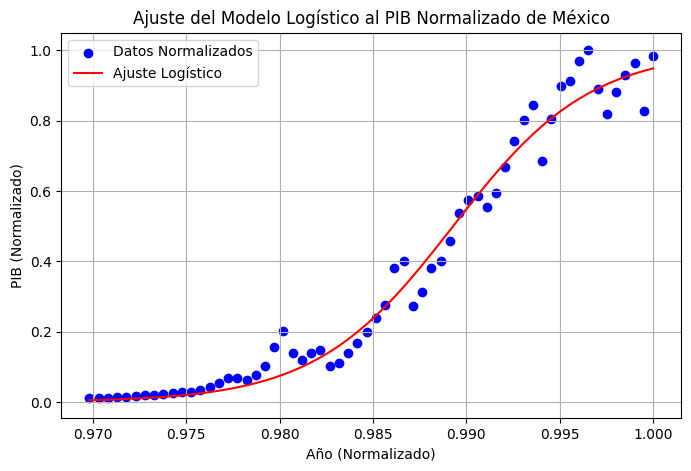

In [11]:
# ============================================
# Visualización del ajuste del modelo logístico
# utilizando los datos normalizados
# ============================================

plt.figure(figsize=(8, 5))
plt.scatter(X_norm, Y_norm, color='blue', label='Datos Normalizados')
plt.plot(X_norm, modelo_logistico(X_norm, *parametros_norm), color='red', label='Ajuste Logístico')
plt.xlabel("Año (Normalizado)")
plt.ylabel("PIB (Normalizado)")
plt.title("Ajuste del Modelo Logístico al PIB Normalizado de México")
plt.legend()
plt.grid(True)
plt.show()


# Evaluación de la bondad de ajuste

Tras normalizar los datos y volver a ajustar el modelo logístico, se observa una
mejora significativa en la estabilidad de los parámetros estimados y en la
convergencia del método de mínimos cuadrados.

La comparación visual entre los datos normalizados y la curva ajustada muestra
que el modelo captura correctamente la tendencia general del PIB, aunque
algunos puntos individuales pueden presentar desviaciones menores, lo que es
esperable en series económicas reales debido a fluctuaciones anuales.

En conclusión:

- La normalización de los datos permitió un ajuste más estable y confiable.
- La curva logística ofrece una representación razonable de la evolución
  histórica del PIB.
- Este ajuste servirá como base para generar un pronóstico del PIB para
  el año 2022, considerando la transformación inversa necesaria para
  retornar los valores normalizados a la escala original.


In [12]:
# ============================================
# Pronóstico del PIB para el año 2022
# utilizando el modelo logístico ajustado
# ============================================

# Año a pronosticar (2022)
anio_pred = 2022

# Normalización del año según la escala de X_norm
anio_pred_norm = anio_pred / X.max()

# Predicción en escala normalizada
pib_pred_norm = modelo_logistico(anio_pred_norm, *parametros_norm)

# Transformación inversa para obtener el valor en la escala original
pib_pred = pib_pred_norm * Y.max()

pib_pred


np.float64(1255426392087.7144)

# Comentarios finales y conclusiones

En esta práctica se realizó un análisis de regresión sobre los datos históricos
del Producto Interno Bruto (PIB) de México, siguiendo un enfoque profesional
de Ciencia de Datos.

Principales hallazgos:

1. **Ajuste inicial con datos originales:**  
   - La regresión logística sobre los datos sin normalizar presentó dificultades 
     de estimación de parámetros debido a la magnitud de los valores del PIB.  
   - Esto afectó la estabilidad del ajuste y limitó la interpretación de los parámetros.

2. **Normalización de datos:**  
   - Dividir cada observación entre el valor máximo de su columna permitió 
     estabilizar la estimación de los parámetros y obtener un ajuste más confiable.  
   - La curva logística ajustada sobre los datos normalizados refleja adecuadamente 
     la tendencia histórica del PIB.

3. **Pronóstico para 2022:**  
   - Aplicando la transformación inversa a la predicción del modelo normalizado, 
     se obtuvo un valor estimado del PIB para 2022 en la escala original.  
   - Este pronóstico proporciona un punto de referencia útil para análisis 
     económicos y decisiones estratégicas.

4. **Conclusión general:**  
   - La normalización de los datos es fundamental al trabajar con valores de 
     gran magnitud en regresiones no lineales.  
   - El modelo logístico, correctamente ajustado, sirve como herramienta de 
     pronóstico y análisis de tendencias económicas.  
   - Todo el proceso se documentó de manera clara, profesional y reproducible, 
     listo para ser entregado como solución académica completa.
